['Belgium' 'Morocco']
[nan 'Michy Batshuayi Tunga' 'Axel Witsel' 'Toby Alderweireld'
 'Amadou Onana' 'Jan Vertonghen' 'Thomas Meunier' 'Kevin De Bruyne'
 'Hakim Ziyech' 'Thibaut Courtois' 'Timothy Castagne' 'Thorgan Hazard'
 'Selim Amallah' 'Romain Saïss' 'Nayef Aguerd' 'Achraf Hakimi Mouh'
 'Sofiane Boufal' 'Sofyan Amrabat' 'Eden Hazard' 'Youssef En-Nesyri'
 'Azzedine Ounahi' 'Noussair Mazraoui' 'Munir Mohand Mohamedi'
 'Youri Tielemans' 'Dries Mertens' 'Yahia Attiyat allah'
 'Abdelhamid Sabiri' 'Leandro Trossard' 'Abderrazak Hamdallah'
 'Zakaria Aboukhlal' 'Jawad El Yamiq' 'Charles De Ketelaere'
 'Romelu Lukaku Menama']
Belgium players: ['Michy Batshuayi Tunga', 'Axel Witsel', 'Toby Alderweireld', 'Amadou Onana', 'Jan Vertonghen', 'Thomas Meunier', 'Kevin De Bruyne', 'Thibaut Courtois', 'Timothy Castagne', 'Thorgan Hazard', 'Eden Hazard', 'Youri Tielemans', 'Dries Mertens', 'Leandro Trossard', 'Charles De Ketelaere', 'Romelu Lukaku Menama']
Morocco players: ['Hakim Ziyech', 'Selim Am

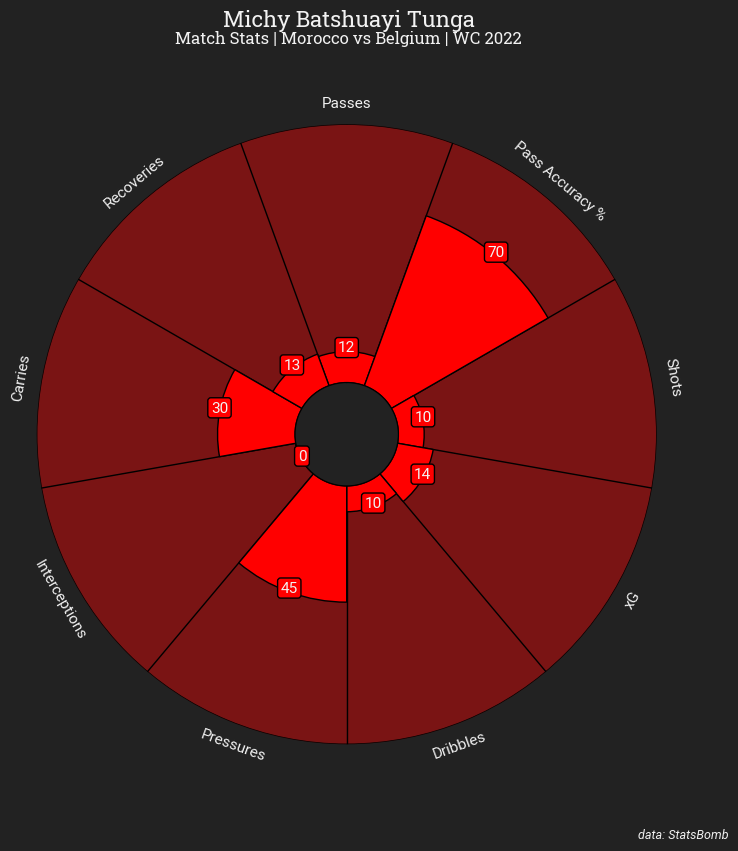

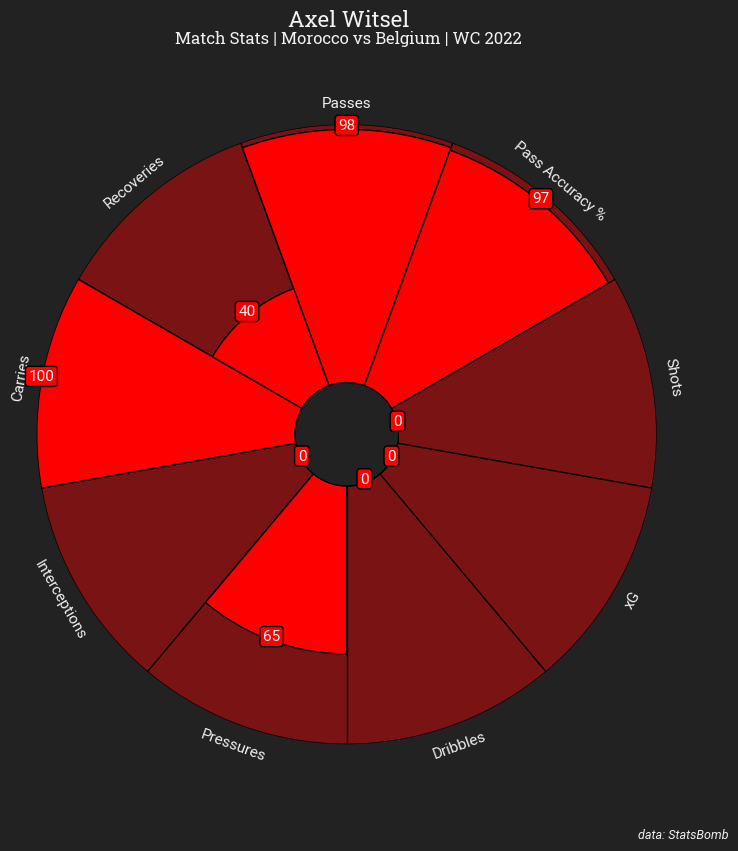

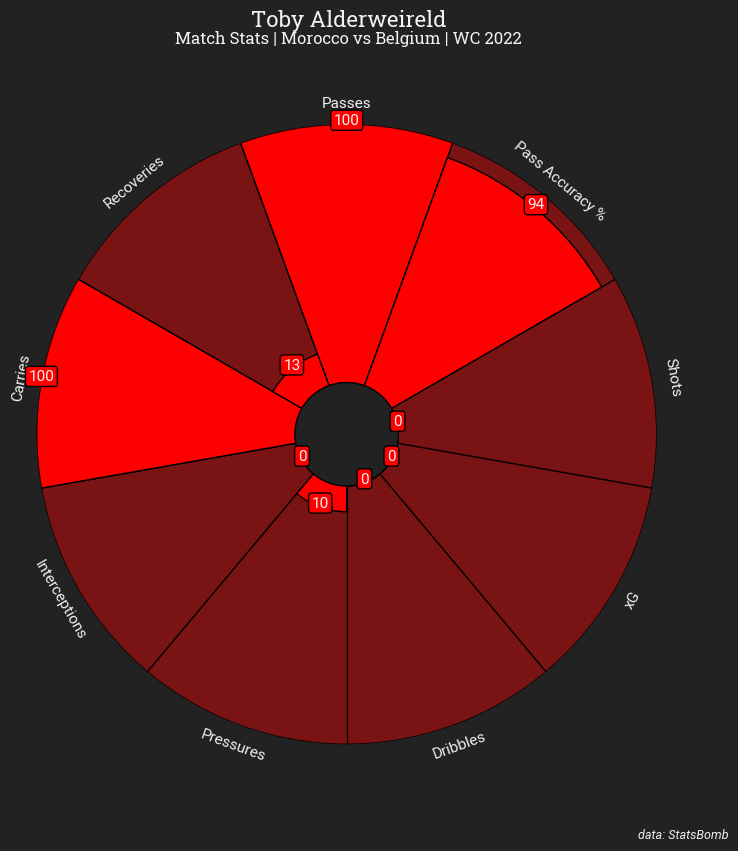

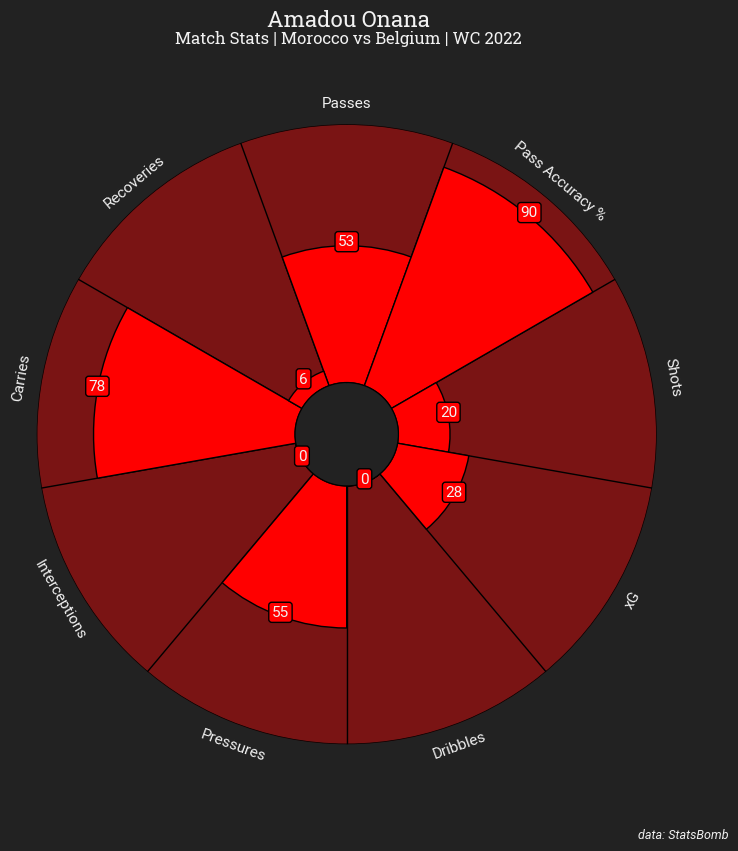

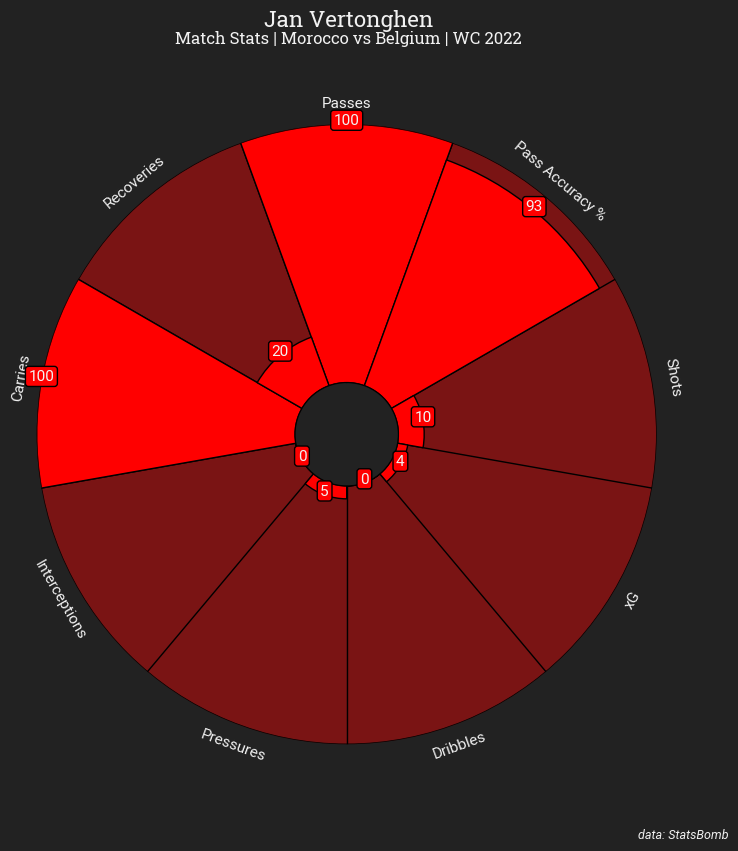

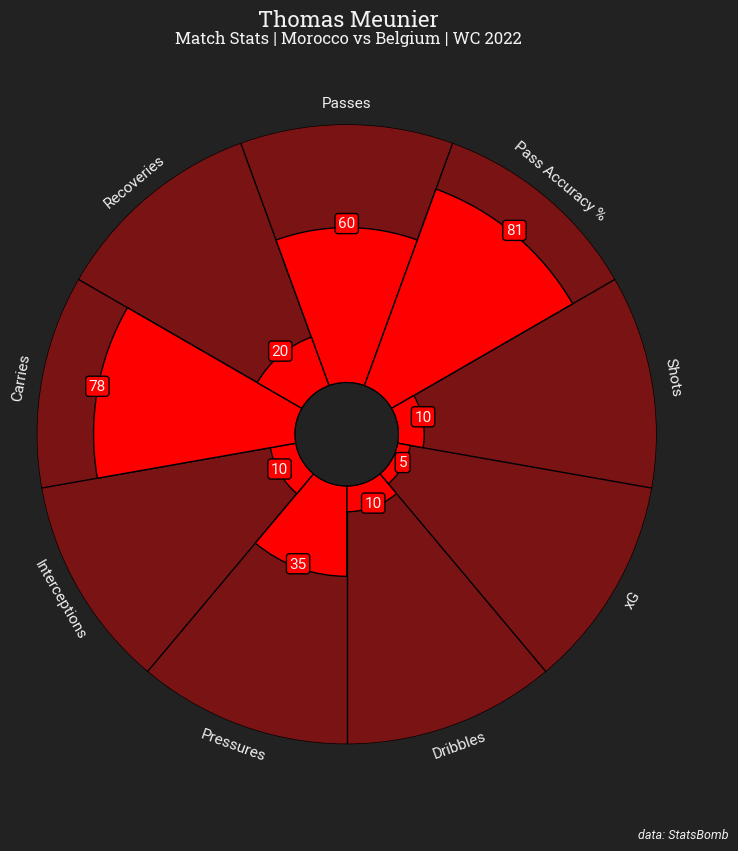

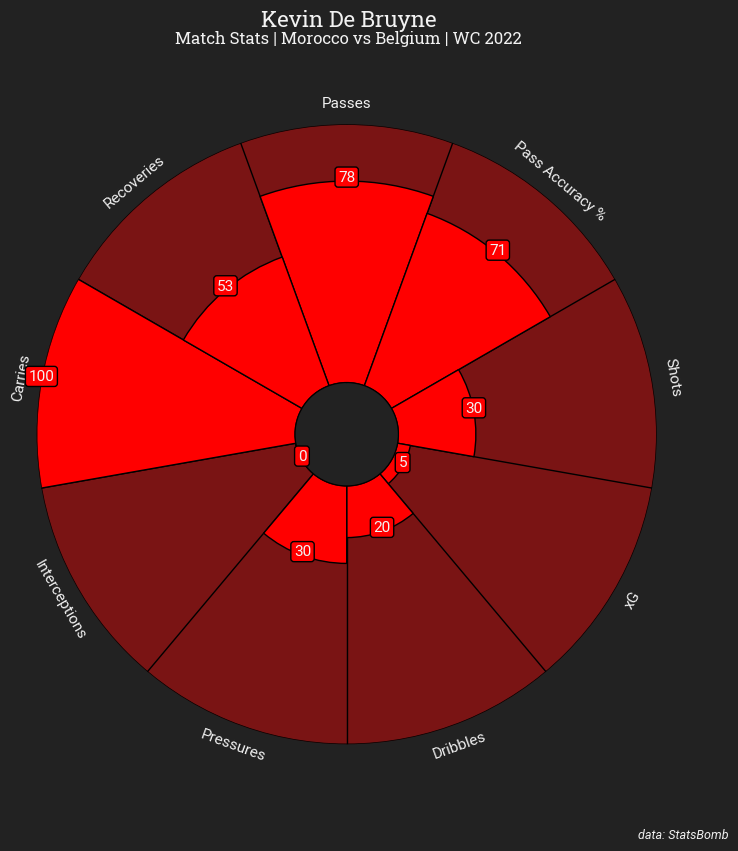

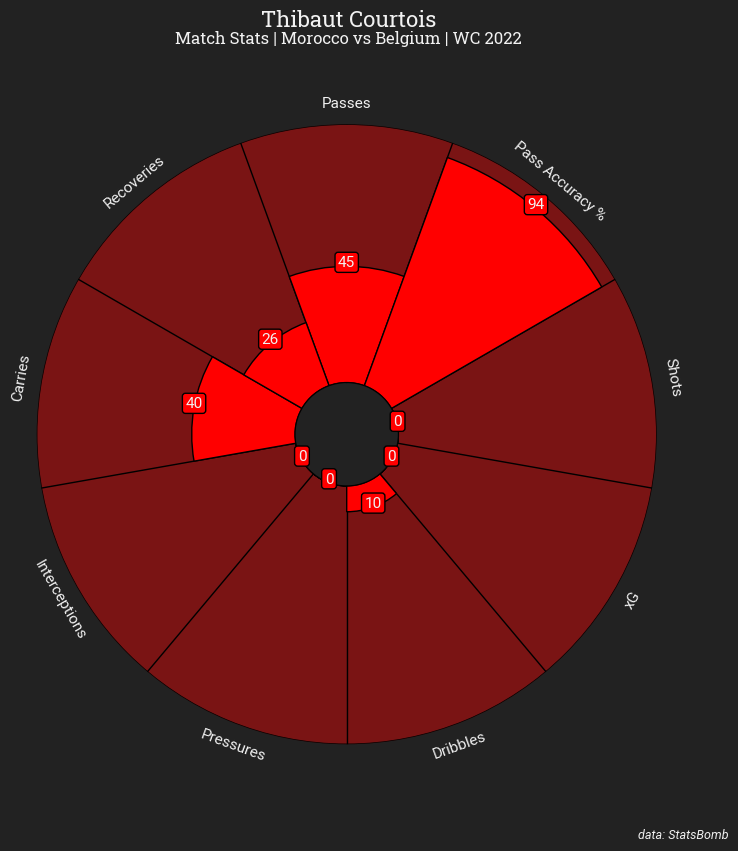

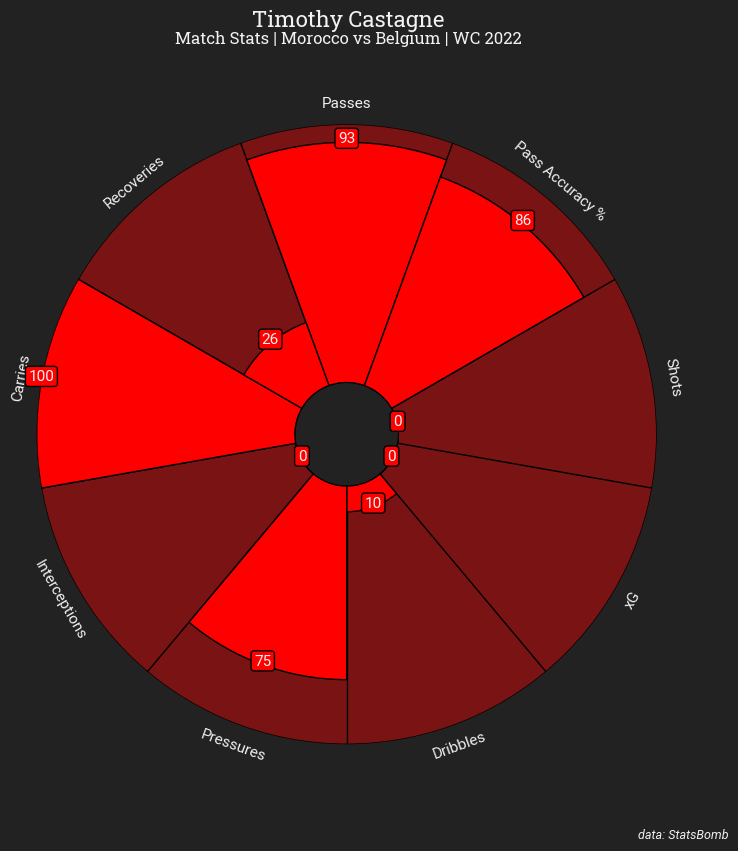

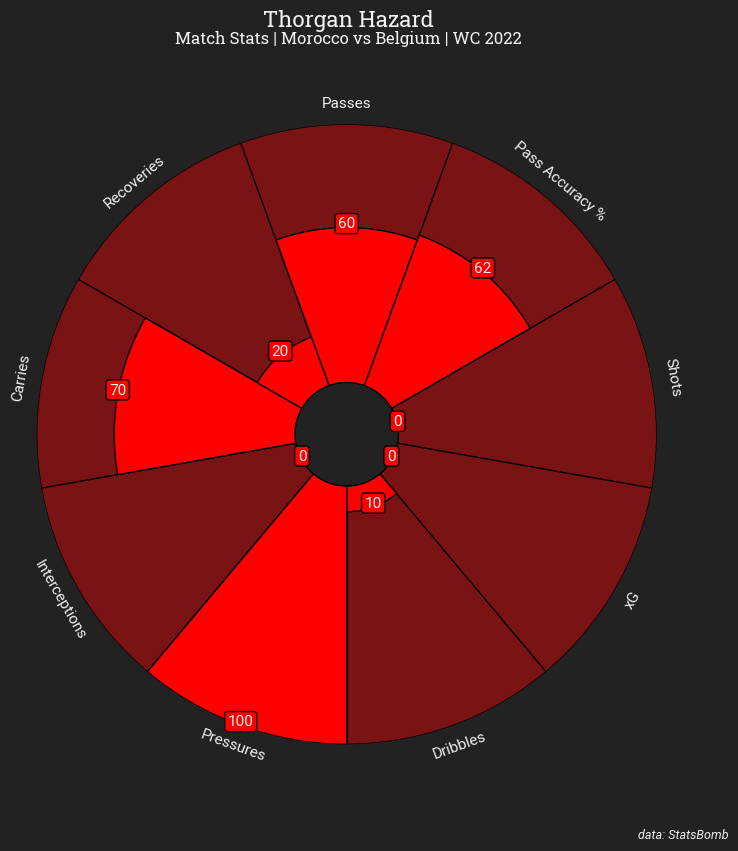

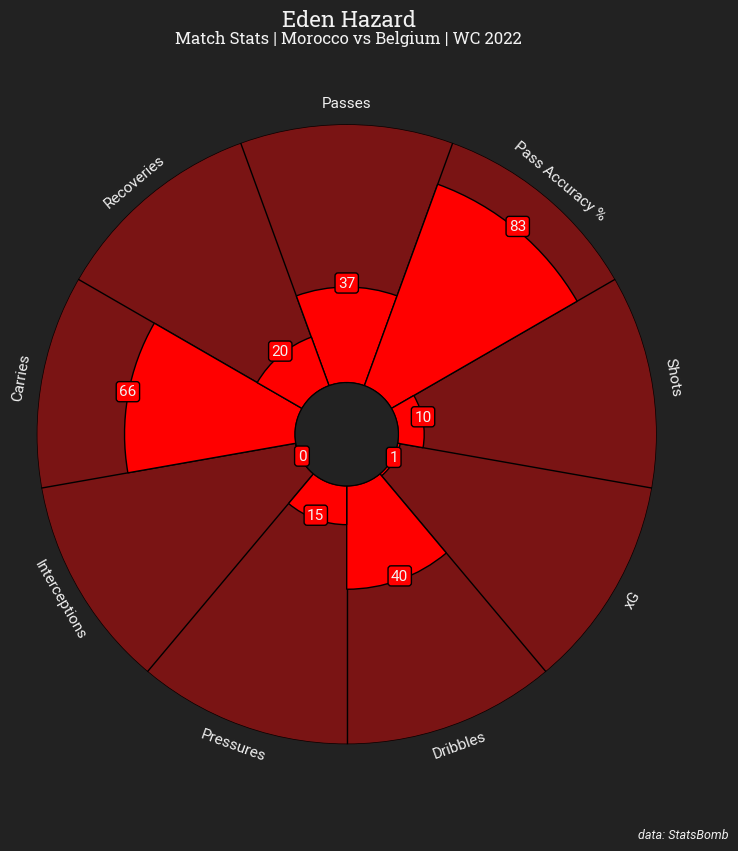

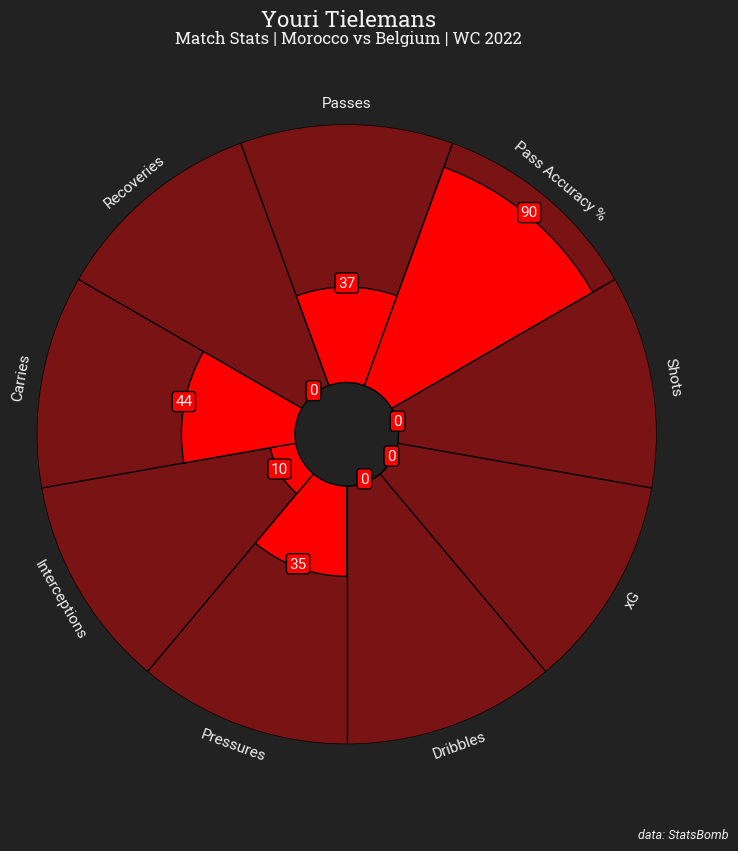

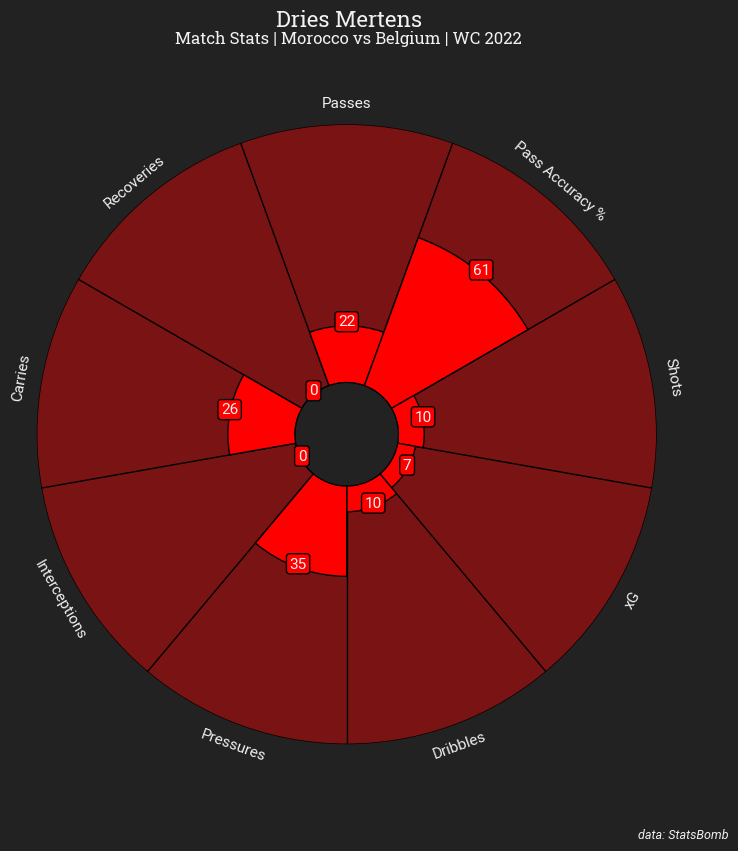

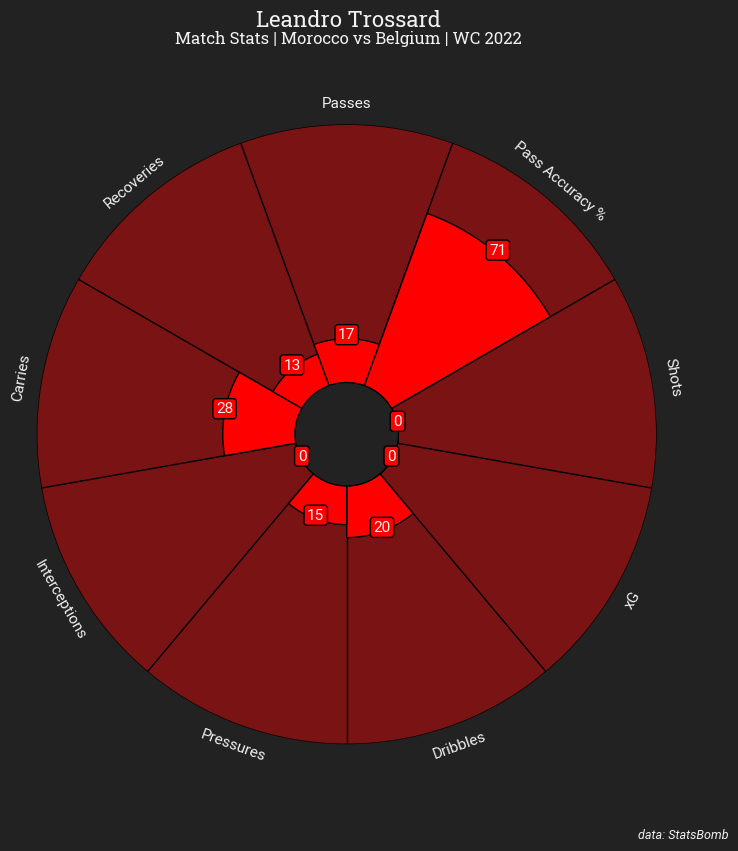

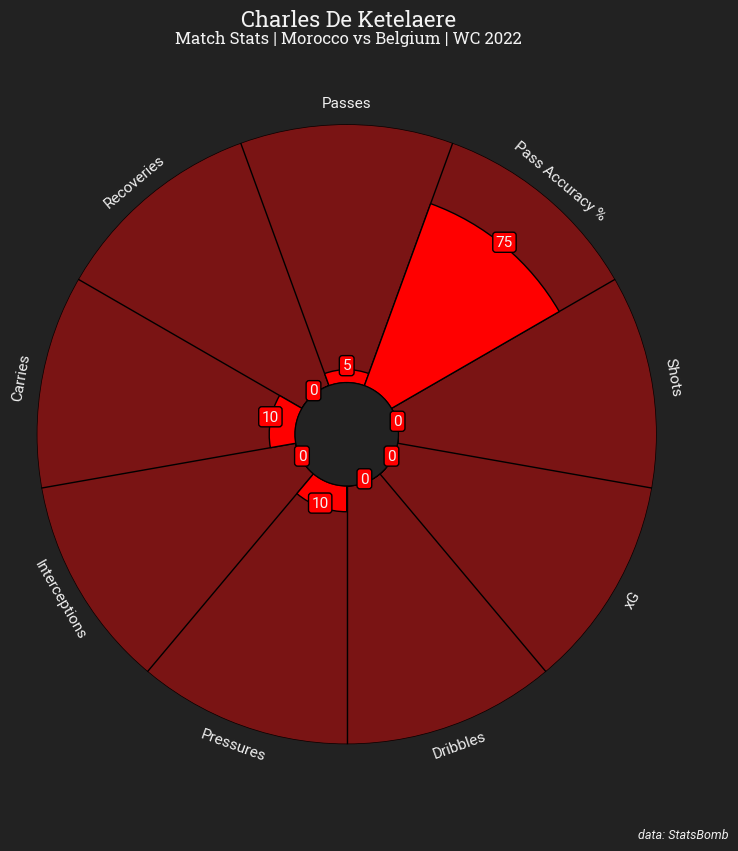

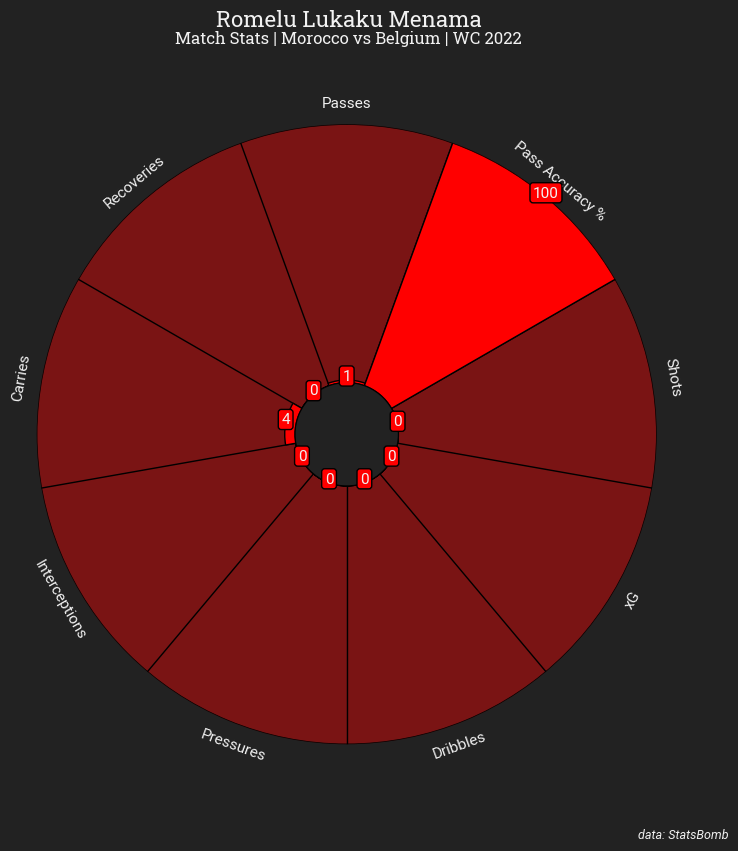

MOROCCO PLAYERS


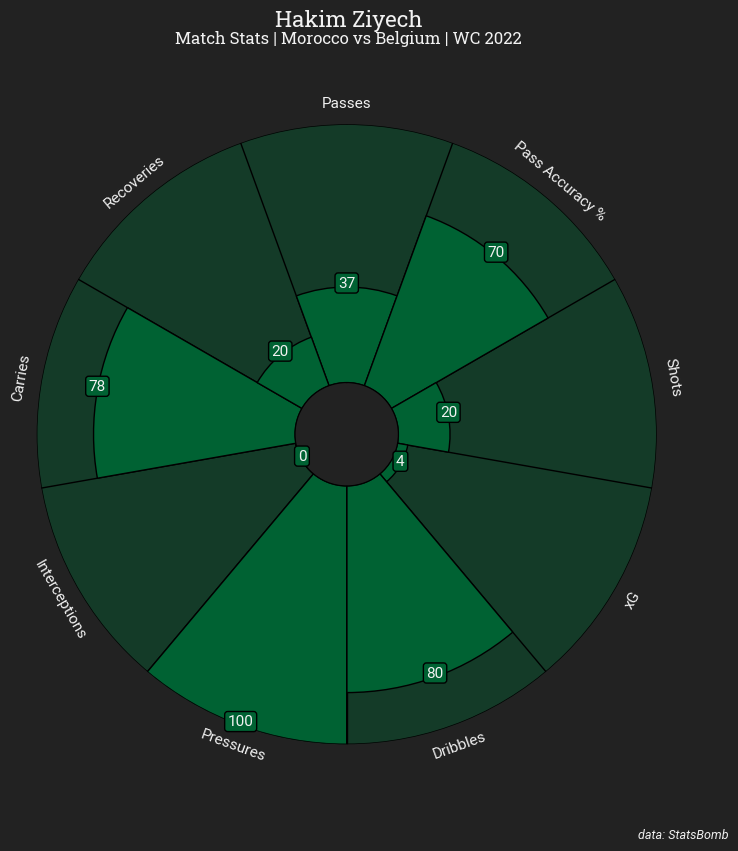

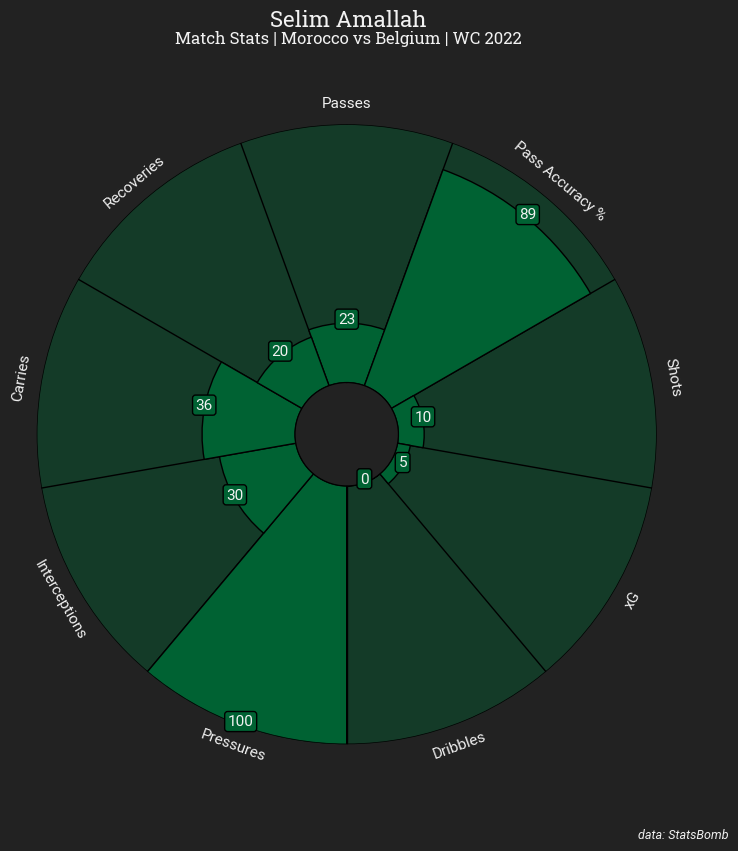

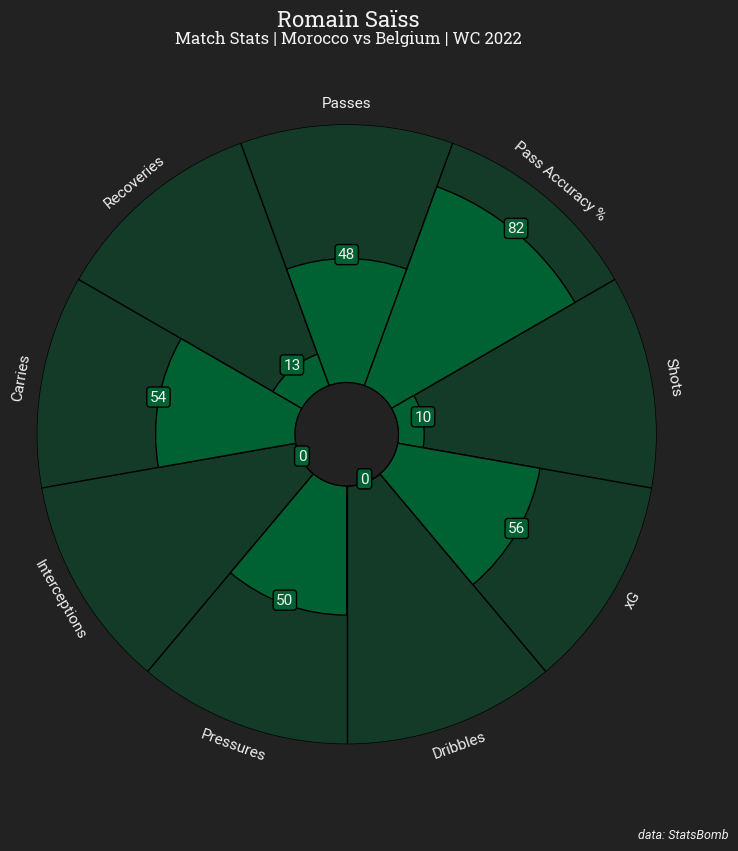

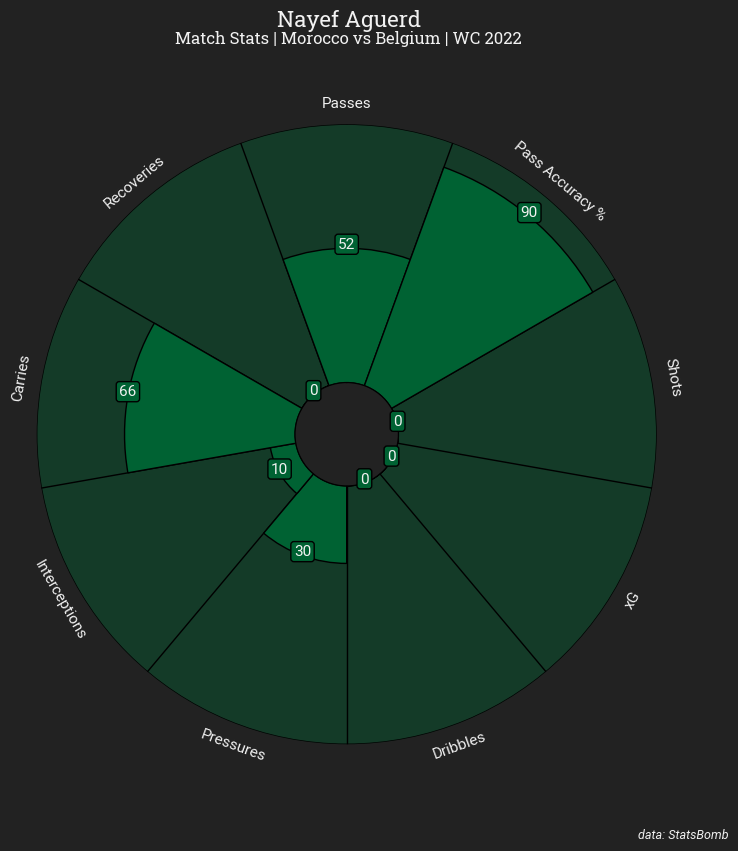

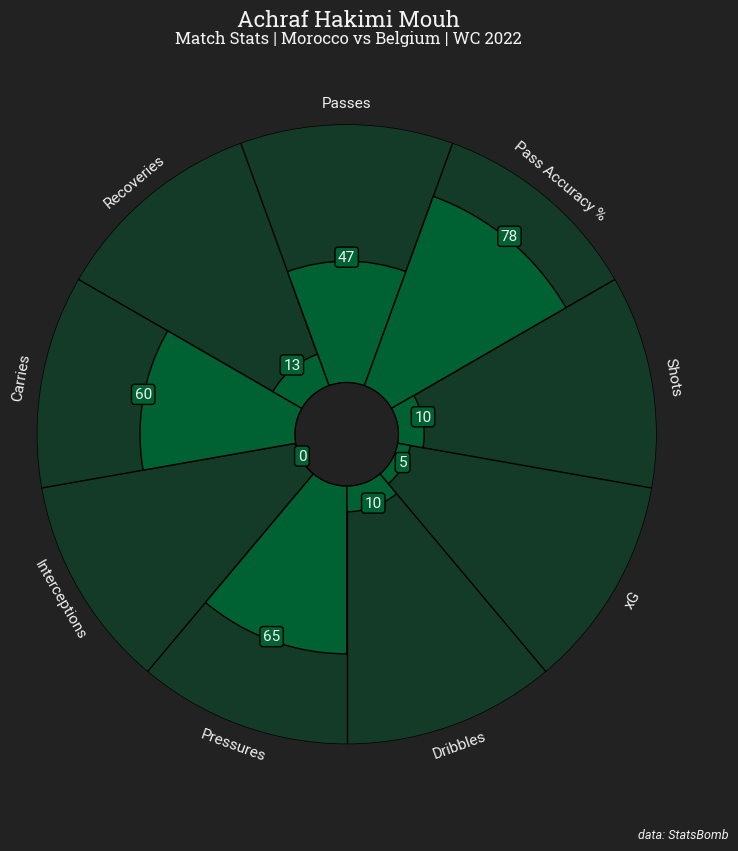

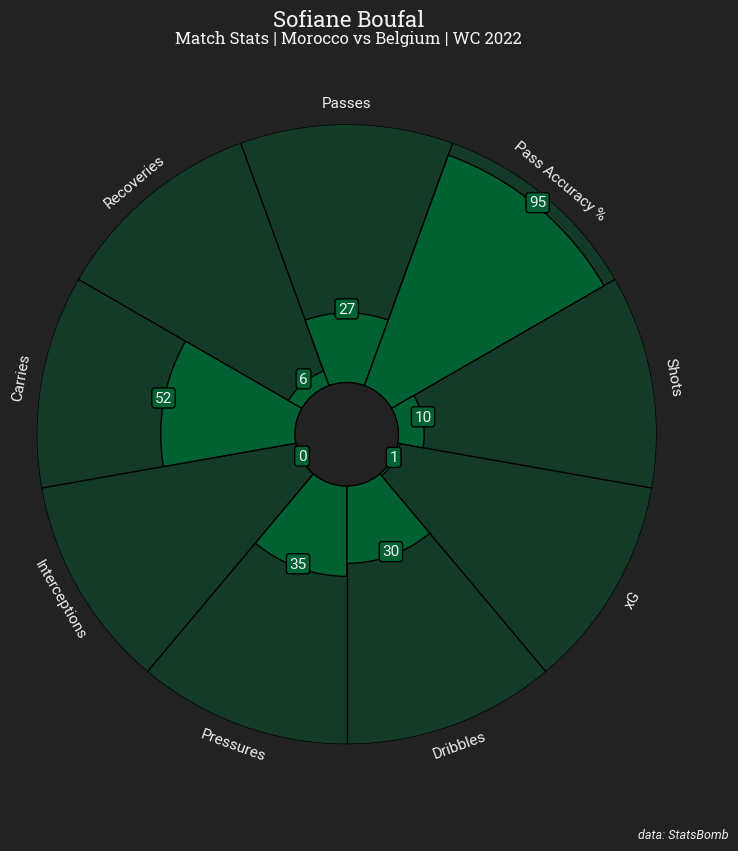

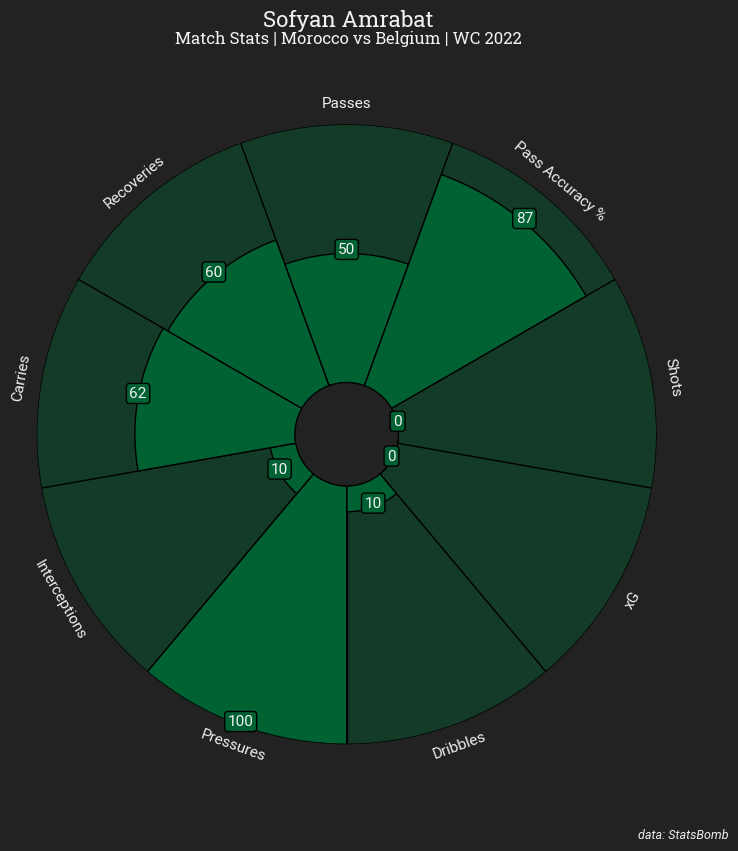

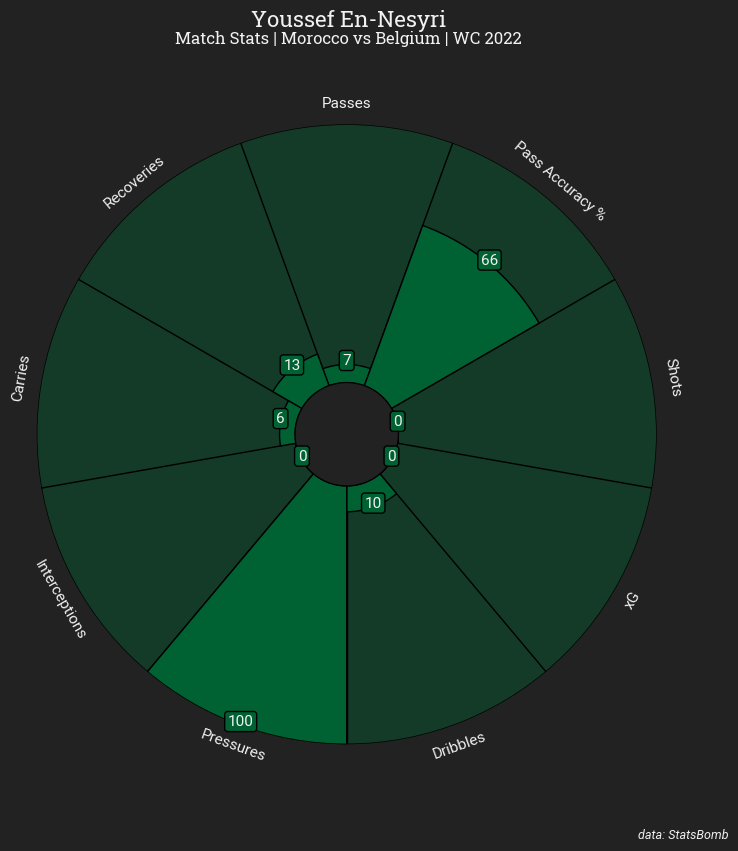

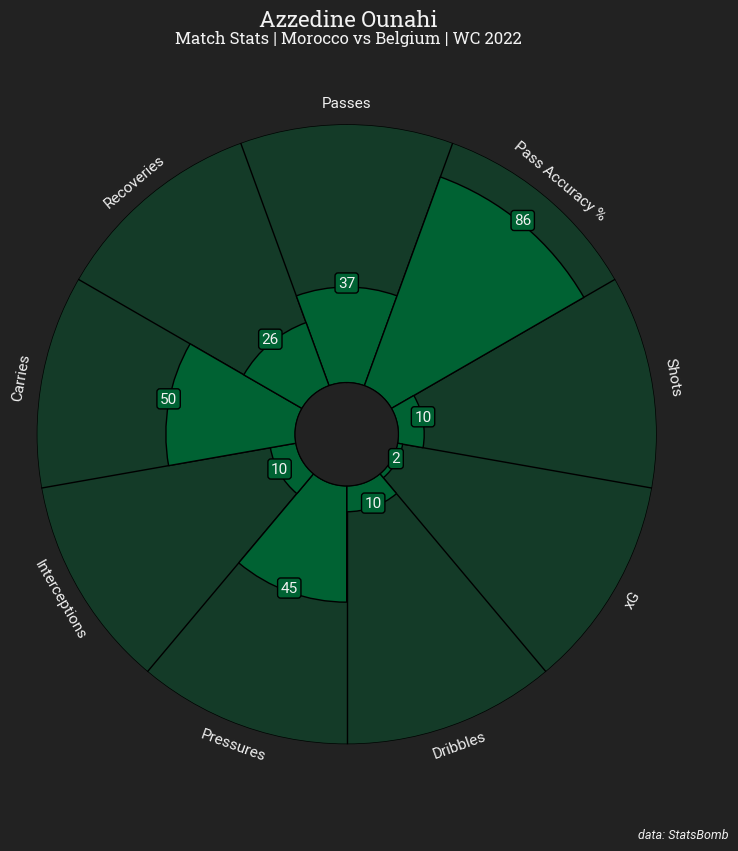

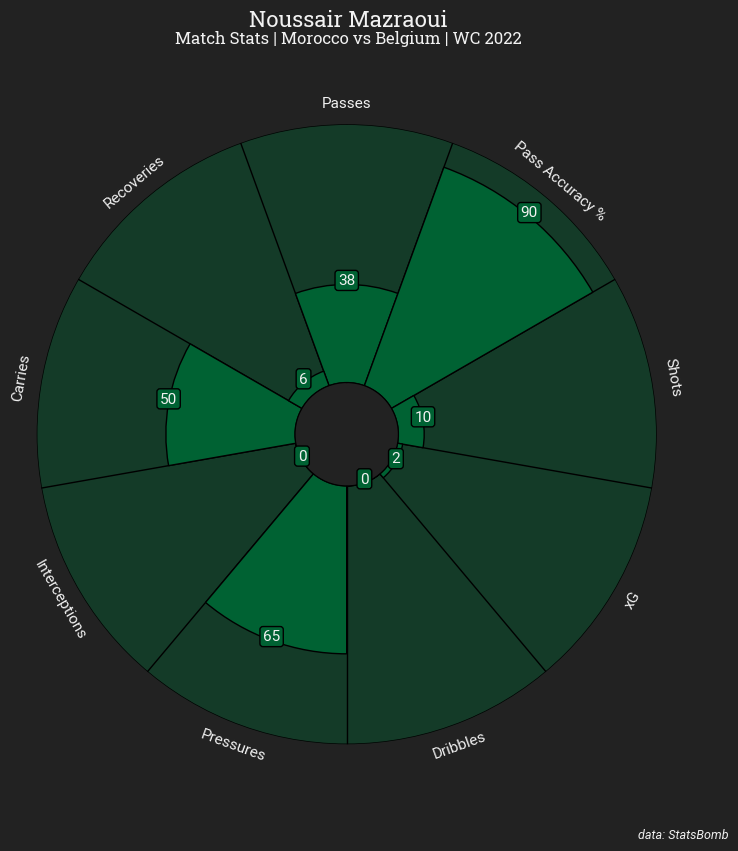

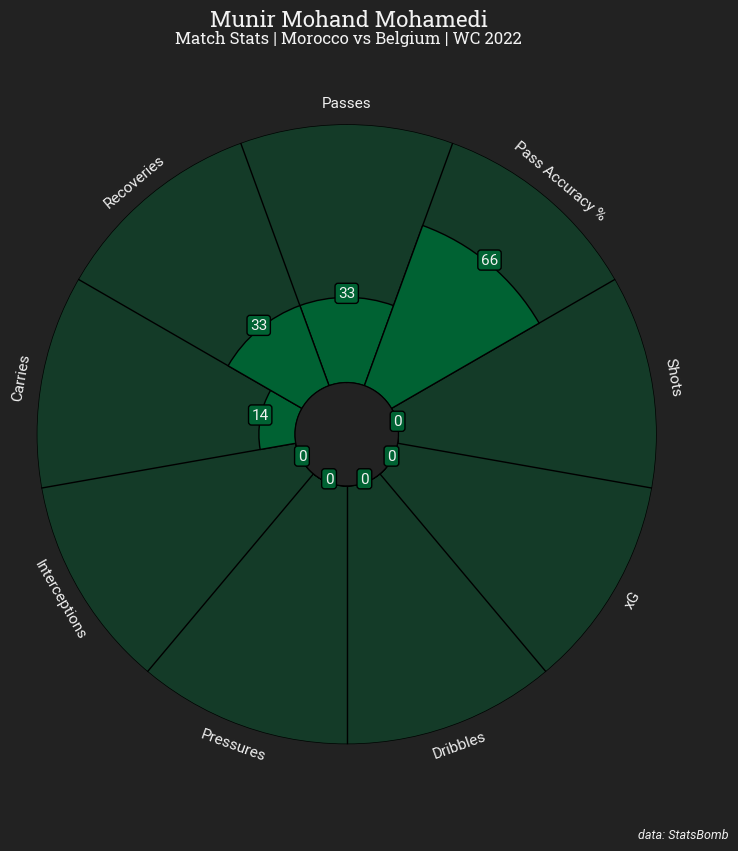

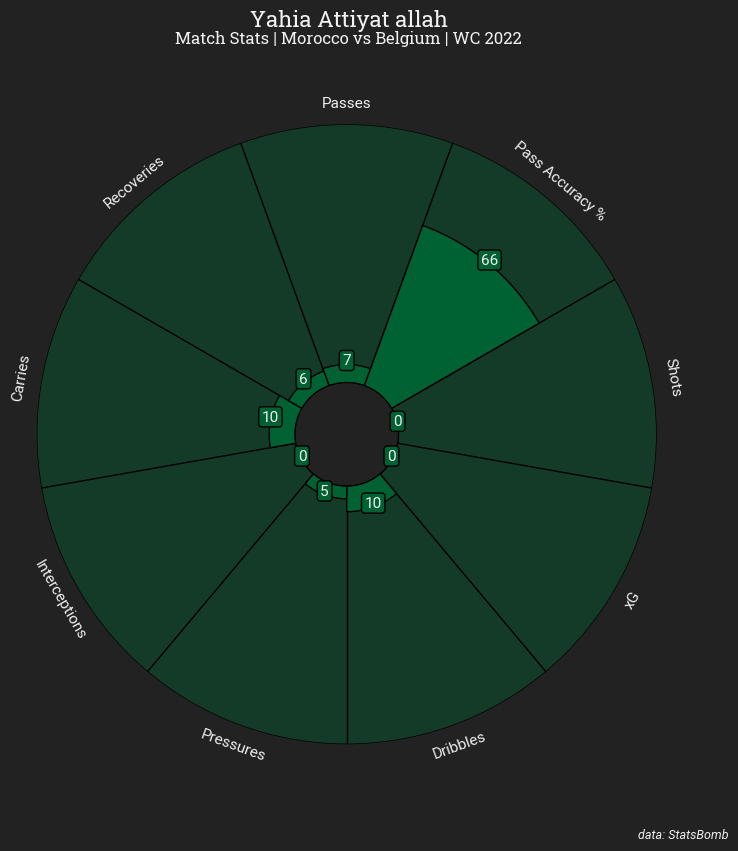

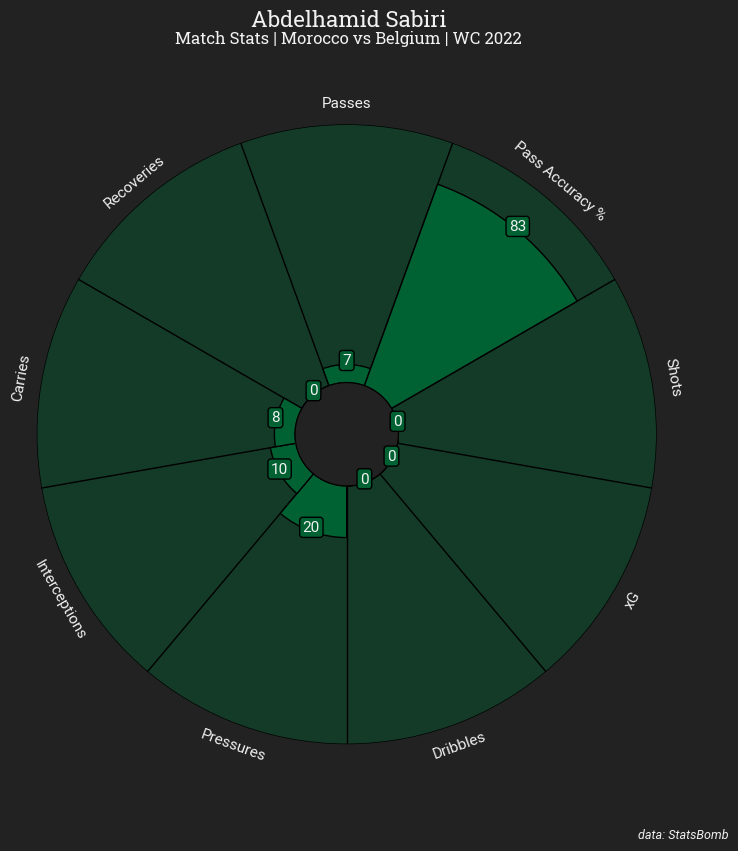

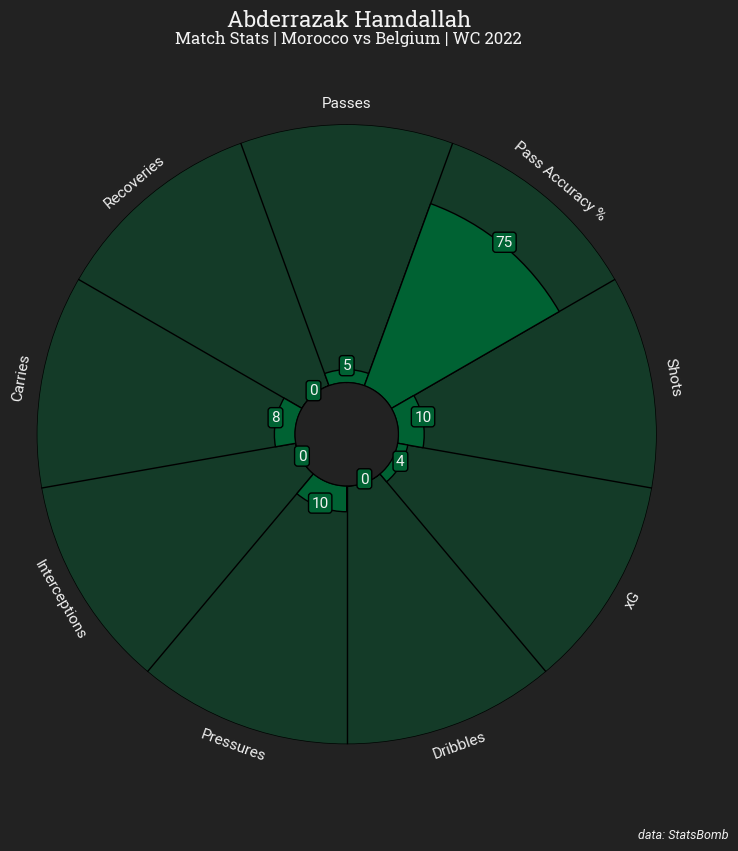

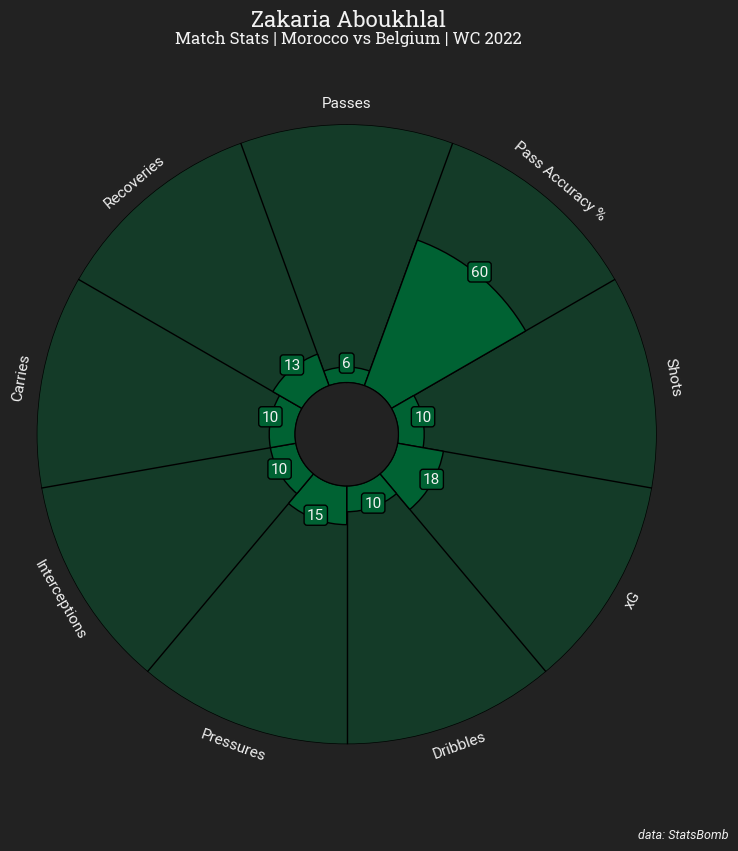

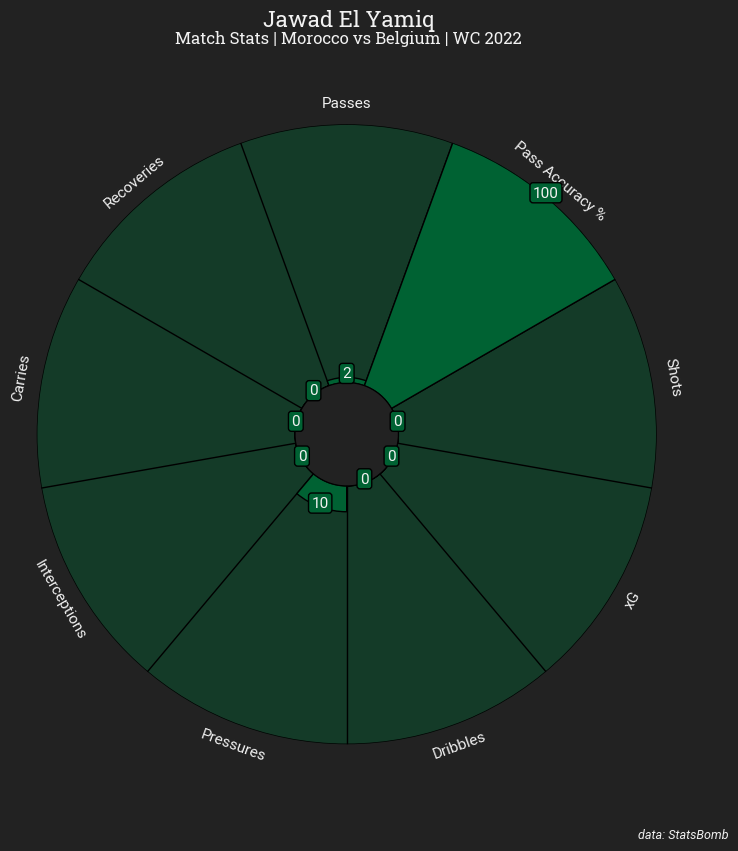

In [21]:
# ── Check available teams & players ──────────────────────────────────────────
print(events['team'].unique())
print(events['player'].unique())

# ── Compute stats per player ──────────────────────────────────────────────────
def get_player_stats(events, player_name):
    p = events[events['player'] == player_name]

    passes        = p[p['type'] == 'Pass']
    shots         = p[p['type'] == 'Shot']
    dribbles      = p[p['type'] == 'Dribble']
    pressures     = p[p['type'] == 'Pressure']
    interceptions = p[p['type'] == 'Interception']
    carries       = p[p['type'] == 'Carry']
    recoveries    = p[p['type'] == 'Ball Recovery']

    stats = {
        'Passes'         : len(passes),
        'Pass Accuracy %': round(len(passes[passes['pass_outcome'].isna()]) / len(passes) * 100, 1) if len(passes) > 0 else 0,
        'Shots'          : len(shots),
        'xG'             : round(shots['shot_statsbomb_xg'].sum(), 2),
        'Dribbles'       : len(dribbles),
        'Pressures'      : len(pressures),
        'Interceptions'  : len(interceptions),
        'Carries'        : len(carries),
        'Recoveries'     : len(recoveries),
    }
    return stats

# ── Pizza plot function ───────────────────────────────────────────────────────
def plot_pizza(player_name, team_color):
    stats = get_player_stats(events, player_name)
    params = list(stats.keys())
    values = list(stats.values())

    max_vals = {'Passes': 80, 'Pass Accuracy %': 100, 'Shots': 10, 'xG': 1.0,
                'Dribbles': 10, 'Pressures': 20, 'Interceptions': 10,
                'Carries': 50, 'Recoveries': 15}
    values_pct = [min(int(v / max_vals[p] * 100), 100) for p, v in zip(params, values)]

    n = len(params)
    slice_colors = [team_color] * n
    text_colors  = ["#F2F2F2"] * n

    baker = PyPizza(
        params=params,
        background_color="#222222",
        straight_line_color="#000000",
        straight_line_lw=1,
        last_circle_color="#000000",
        last_circle_lw=1,
        other_circle_lw=0,
        inner_circle_size=20
    )

    fig, ax = baker.make_pizza(
        values_pct,
        figsize=(8, 8.5),
        color_blank_space="same",
        slice_colors=slice_colors,
        value_colors=text_colors,
        value_bck_colors=slice_colors,
        blank_alpha=0.4,
        kwargs_slices=dict(edgecolor="#000000", zorder=2, linewidth=1),
        kwargs_params=dict(color="#F2F2F2", fontsize=11,
                           fontproperties=font_normal.prop, va="center"),
        kwargs_values=dict(color="#F2F2F2", fontsize=11,
                           fontproperties=font_normal.prop, zorder=3,
                           bbox=dict(edgecolor="#000000", facecolor=team_color,
                                     boxstyle="round,pad=0.2", lw=1))
    )

    fig.text(0.515, 0.975, player_name, size=16,
             ha="center", fontproperties=font_bold.prop, color="#F2F2F2")
    fig.text(0.515, 0.955, "Match Stats | Morocco vs Belgium | WC 2022", size=12,
             ha="center", fontproperties=font_bold.prop, color="#F2F2F2")
    fig.text(0.99, 0.02, "data: StatsBomb", size=9,
             fontproperties=font_italic.prop, color="#F2F2F2", ha="right")

    plt.show()

# ── Get exact player names from StatsBomb data ────────────────────────────────
belgium_players = events[events['team'] == 'Belgium']['player'].dropna().unique().tolist()
morocco_players = events[events['team'] == 'Morocco']['player'].dropna().unique().tolist()

print("Belgium players:", belgium_players)
print("Morocco players:", morocco_players)

# ── Plot for all players ──────────────────────────────────────────────────────
print("=" * 40)
print("BELGIUM PLAYERS")
print("=" * 40)
for player in belgium_players:
    plot_pizza(player, team_color='#FF0000')

print("=" * 40)
print("MOROCCO PLAYERS")
print("=" * 40)
for player in morocco_players:
    plot_pizza(player, team_color='#006233')